# General N-Direction Walk (Demo)

This notebook generalizes the 2D walk to `N_DIRECTIONS` evenly spaced directions.
Change the knobs below and rerun for quick experimentation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils import (
    compute_planar_metrics,
    ensure_output_dirs,
    plot_histogram,
    plot_overlay_2d_solution_split,
    plot_single_walk_2d,
    run_general_walk_trials,
    save_summary_csv,
    simulate_general_walk,
    split_paths_by_solution,
)

# Demo knobs: tweak these and rerun the notebook.
RANDOM_SEED = 42
N_TRIALS = 10
MAX_STEPS = 20_000
N_DIRECTIONS = 8

# For non-lattice N, return detection uses tolerance.
RETURN_TOLERANCE = 1e-9
POSITION_ROUND_DECIMALS = 12

NOTEBOOK_DIR = Path('.')
OUTPUT_DIR, PATHS_DIR = ensure_output_dirs(NOTEBOOK_DIR / 'outputs' / 'general_walk_solution')

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(RANDOM_SEED)

print(f'Output folder: {OUTPUT_DIR.resolve()}')
print(f'RANDOM_SEED={RANDOM_SEED}, N_TRIALS={N_TRIALS}, MAX_STEPS={MAX_STEPS}, N_DIRECTIONS={N_DIRECTIONS}')

Output folder: /home/manpazito/projects/fun_mini_sims/random_walks/outputs/general_walk_solution
RANDOM_SEED=42, N_TRIALS=10, MAX_STEPS=20000, N_DIRECTIONS=8


## Walk Model

At each step choose angle $\frac{2k\pi}{N}$ uniformly and move one unit.

Notes:
- `N_DIRECTIONS = 4` reproduces the mathemagicland model.
- For many `N_DIRECTIONS` values, exact floating-point return checks are unstable,
  so this notebook uses tolerance-based return detection.

## Single Example Walk

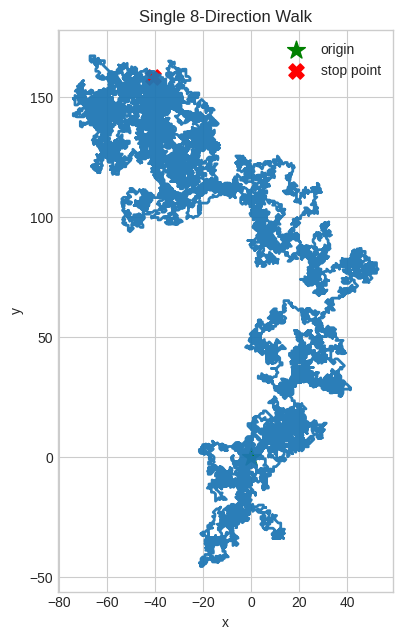

Single walk:
  steps_until_stop: 20000
  returned_to_origin: False
  saved: outputs/general_walk_solution/single_walk.png


In [2]:
single_walk = simulate_general_walk(
    rng=rng,
    n_directions=N_DIRECTIONS,
    max_steps=MAX_STEPS,
    return_tolerance=RETURN_TOLERANCE,
    round_decimals=POSITION_ROUND_DECIMALS,
)

single_walk_plot_path = OUTPUT_DIR / 'single_walk.png'
plot_single_walk_2d(
    xs=single_walk['xs'],
    ys=single_walk['ys'],
    out_path=single_walk_plot_path,
    title=f'Single {N_DIRECTIONS}-Direction Walk',
)

print('Single walk:')
print(f"  steps_until_stop: {single_walk['steps_until_stop']}")
print(f"  returned_to_origin: {single_walk['returned_to_origin']}")
print(f"  saved: {single_walk_plot_path}")

## Monte Carlo Simulation

In [3]:
summary_df, all_paths = run_general_walk_trials(
    rng=rng,
    n_trials=N_TRIALS,
    max_steps=MAX_STEPS,
    n_directions=N_DIRECTIONS,
    return_tolerance=RETURN_TOLERANCE,
    round_decimals=POSITION_ROUND_DECIMALS,
    paths_dir=PATHS_DIR,
)

summary_csv_path = save_summary_csv(summary_df, OUTPUT_DIR / 'summary.csv')
metrics = compute_planar_metrics(summary_df, distance_col='max_distance')

print('Monte Carlo summary:')
print(f"  completed_trials: {metrics['completed_trials']}")
print(f"  censored_trials: {metrics['censored_trials']}")
print(f"  mean_return_time: {metrics['mean_return_time']:.3f}")
print(f"  mean_max_distance: {metrics['mean_max_distance']:.3f}")
print(f"  saved: {summary_csv_path}")

summary_df.head()

Monte Carlo summary:
  completed_trials: 1
  censored_trials: 9
  mean_return_time: 6.000
  mean_max_distance: 130.779
  saved: outputs/general_walk_solution/summary.csv


,trial_index,n_directions,steps_until_stop,return_time,returned_to_origin,censored,max_distance,max_manhattan,bbox_width,bbox_height,bbox_area,final_x,final_y
0,0,8,6,6.0,True,False,1.000000,1.414214,1.707107,0.707107,1.207107,0.000000,0.000000
1,1,8,20000,NaN,False,True,165.958663,228.977705,134.530483,163.672619,22018.956518,83.488853,-134.145707
2,2,8,20000,NaN,False,True,156.858680,209.053824,187.915260,162.911688,30613.592186,-70.003571,-2.393398
3,3,8,20000,NaN,False,True,84.582243,101.811183,87.417785,147.752309,12916.179539,15.778175,-80.175144
4,4,8,20000,NaN,False,True,111.284671,136.296465,86.707107,133.760931,11598.023297,-11.819805,-45.974134


## Distribution Plots

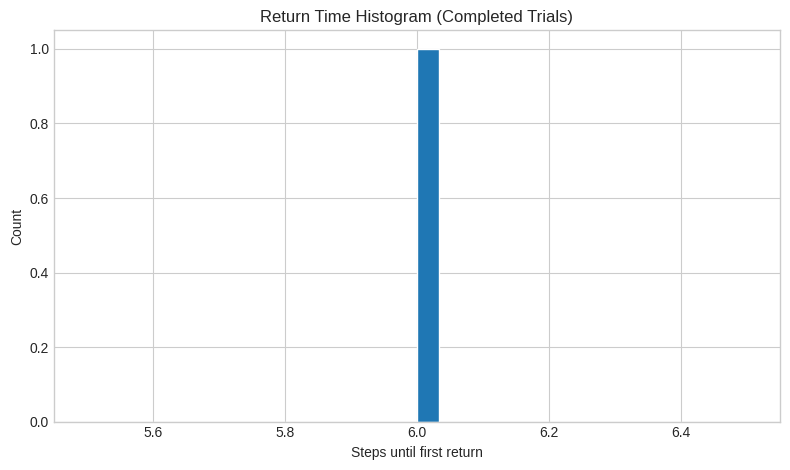

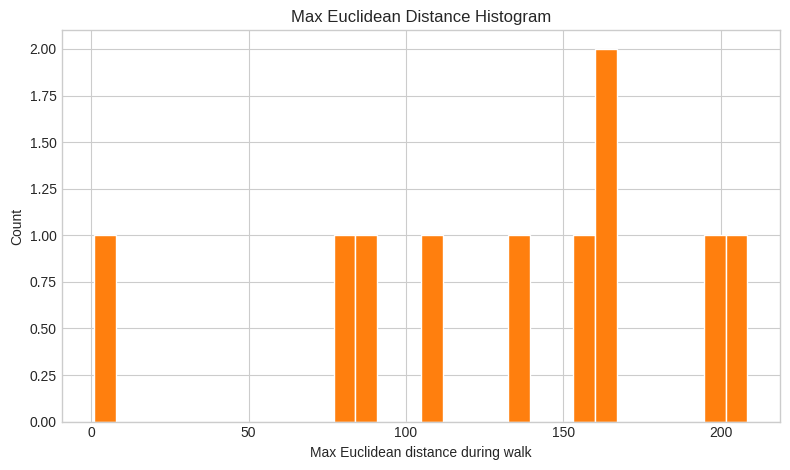

saved: outputs/general_walk_solution/return_time_histogram.png
saved: outputs/general_walk_solution/max_distance_histogram.png


In [4]:
completed_return_times = summary_df.loc[~summary_df['censored'], 'return_time']

return_hist_path = OUTPUT_DIR / 'return_time_histogram.png'
max_dist_hist_path = OUTPUT_DIR / 'max_distance_histogram.png'

plot_histogram(
    values=completed_return_times,
    out_path=return_hist_path,
    title='Return Time Histogram (Completed Trials)',
    xlabel='Steps until first return',
    color='tab:blue',
)

plot_histogram(
    values=summary_df['max_distance'],
    out_path=max_dist_hist_path,
    title='Max Euclidean Distance Histogram',
    xlabel='Max Euclidean distance during walk',
    color='tab:orange',
)

print(f'saved: {return_hist_path}')
print(f'saved: {max_dist_hist_path}')

## Final Overlay Plot

Left panel: walks that returned to origin.
Right panel: censored walks.

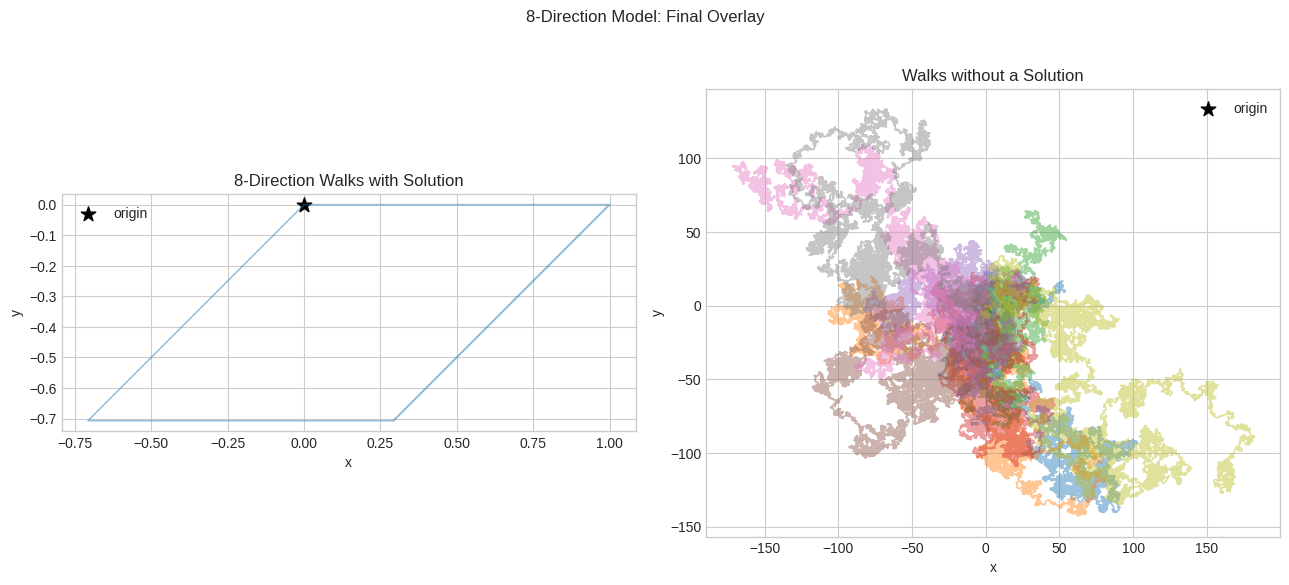

with_solution=1, without_solution=9
saved: outputs/general_walk_solution/overlay_walks.png


In [5]:
paths_with_solution, paths_without_solution = split_paths_by_solution(all_paths, summary_df)

overlay_path = OUTPUT_DIR / 'overlay_walks.png'
plot_overlay_2d_solution_split(
    paths_with_solution=paths_with_solution,
    paths_without_solution=paths_without_solution,
    out_path=overlay_path,
    left_title=f'{N_DIRECTIONS}-Direction Walks with Solution',
    right_title='Walks without a Solution',
    figure_title=f'{N_DIRECTIONS}-Direction Model: Final Overlay',
)

print(f'with_solution={len(paths_with_solution)}, without_solution={len(paths_without_solution)}')
print(f'saved: {overlay_path}')